# GC Example 04: Dynamical Mass vs Metallicity

**EPS Research — Milky Way Globular Cluster Corpus v1.3.1**

Baumgardt N-body masses vs Harris metallicity.
More massive clusters tend to be more metal-rich —
a fossil record of the Milky Way's chemical enrichment history.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907766  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'harris_gc_corpus_v1.3.2.jsonl': 'https://zenodo.org/records/21093446/files/harris_gc_corpus_v1.3.2.jsonl',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.2.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174


Clusters with mass + [Fe/H]: 149
Pearson r ([Fe/H] vs log mass): -0.046


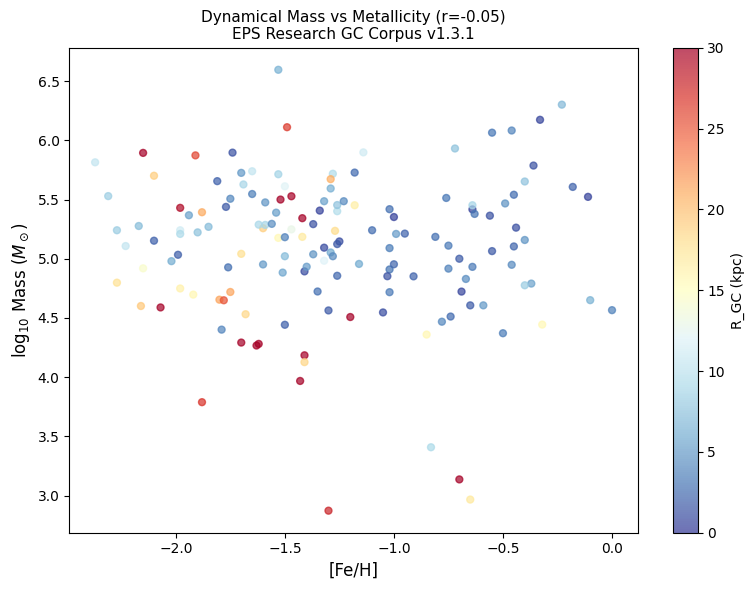

In [3]:
data = []
for c in clusters:
    if (c.get('baumgardt2023') and c['baumgardt2023'].get('mass_msun') and
            c.get('metallicity') and c['metallicity'].get('feh') is not None):
        data.append({'cluster': c['cluster_id'],
                     'mass': c['baumgardt2023']['mass_msun'],
                     'feh':  c['metallicity']['feh'],
                     'r_gc': c['distances'].get('r_gc_kpc', 0) if c.get('distances') else 0})

masses = [d['mass'] for d in data]
fehs   = [d['feh']  for d in data]
r_gcs  = [d['r_gc'] for d in data]

print(f"Clusters with mass + [Fe/H]: {len(data)}")
corr = np.corrcoef(fehs, np.log10(masses))[0, 1]
print(f"Pearson r ([Fe/H] vs log mass): {corr:.3f}")

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(fehs, np.log10(masses), c=r_gcs, s=25, alpha=0.7,
                cmap='RdYlBu_r', vmin=0, vmax=30)
plt.colorbar(sc, ax=ax, label='R_GC (kpc)')
ax.set_xlabel('[Fe/H]', fontsize=12)
ax.set_ylabel(r'log$_{10}$ Mass ($M_\odot$)', fontsize=12)
ax.set_title(f'Dynamical Mass vs Metallicity (r={corr:.2f})\n'
             'EPS Research GC Corpus v1.3.1', fontsize=11)
plt.tight_layout()
plt.savefig('gc04_mass_metallicity.png', dpi=150, bbox_inches='tight')
plt.show()